# SPARC-4 products
***

This notebook shows an example for viewing and accessing the SPARC4 data products.

* Eder Martioli, LNA 18 Apr 2024
* Fernando Falkenberg INPE 09 Oct 2025

In [2]:
from astropy.io import fits, ascii
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sparc4.product_plots as s4plt
import sparc4.pipeline_lib as s4pipelib

### Set paths to example files 
Below we set the paths to the files, which are sparc4-pipeline products.

In [4]:
path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250701'
object = 'V2400_Oph'
channel = '3'

In [5]:
db_example = f'{path}{date}/sparc4acs{channel}/{date}_sparc4acs{channel}_db.csv'
# Esse arquivo é uma tabela que contém informações de todas as imagens daquela noite, naquele canal, por exemplo, diretório, tempo de exposição, posição da lâmina, etc.

phot_lightcurve_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_S+N_lc.fits'
# Esse arquivo contém várias tabelas dentro dele, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela, estão informações de cada uma das fontes detectadas pelo pipeline, para cada imagem daquele objeto, por exemplo, RA, Dec, magnitude (com seu erro), fwhm, etc.

polar_stack_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_stack.fits'
# Esse arquivo contém várias tabelas dentro dele, duas para cada abertura em que os dados do objeto foram processados (sendo uma para o feixe ordinário e a outra para o feixe extraordinário). Cada tabela contém uma linha para cada fonte identificada pelo pipeline. Para cada linha, existem informações como RA, Dec, magnitude (com seu erro), fwhm, etc. É uma versão do arquivo logo acima, só que para apenas uma imagem stack.

polar_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_Gain2_1.0_Conventional_2_{object}_POLAR_L4_polar.fits'
# Esse arquivo contém várias tabelas, uma pra cada abertura em que os dados do objeto foram processados. Dentro de cada tabela existe uma linha para cada fonte detectada pelo pipeline. Em cada linha estão os resultados da polarimetria para aquela fonte, por exemplo, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... Além disso, também estão as contagens para cada posição de lâmina, para cada fonte, para cada imagem, com seus erros. É nesse arquivo que estão os dados importantes.

polar_time_series_example = f'{path}{date}/sparc4acs{channel}/{date}_s4c{channel}_{object}_POLAR_L4_ts.fits'
# Esse arquivo contém uma tabela com os dados da série temporal polarimétrica das fontes detectadas pelo pipeline, por exemplo, RA, Dec, x1, y1, x2, y2, mag, emag, Q, U, V, P, theta, fwhm, zero, ezero, k, chi2, rms... O resultado aqui é para cada conjunto de uma medida polarimétrica.

# DB product example
***
In this simple example, we just read the database created by the `sparc4-pipeline` and print it as a pandas table. It's an easy way to quickly access the log of observations.

In [7]:
db = ascii.read(db_example)
pd.DataFrame(np.array(db))

,FILE,DATE-OBS,EXPTIME,RA,DEC,OBJECT,OBSTYPE,INSTMODE,CHANNEL,VBIN,...,VCLKAMP,CCDSERN,PREAMP,READRATE,EMMODE,EMGAIN,WPPOS,WPSEL,CALW,ASEL
0,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:20.351000,0.4,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,1,L2,None,True
1,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:21.871063,0.4,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,1,L2,None,True
2,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:27.115000,0.4,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,2,L2,None,True
3,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:28.635063,0.4,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,2,L2,None,True
4,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-01T21:53:33.688000,0.4,11:17:12.01,-38:00:51.70,HD98161,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,3,L2,None,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
429,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:06.319000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,8,L4,None,True
430,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T04:59:48.867000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,9,L4,None,True
431,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:00:31.400000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,10,L4,None,True
432,/media/fernando/KINGSTON/Doutorado/2025/202507...,2025-07-02T05:01:13.997000,40.0,22:17:55.38,-08:21:04.60,FO_Aqr,OBJECT,POLAR,3,1,...,Normal,9916,Gain 2,1.0,Conventional,2,11,L4,None,True


# POLAR products example
***
In this example we show how to work with the polarimetric products of SPARC4

We start by reading the science image FITS file and showing its information. 

In [10]:
hdul = fits.open(polar_stack_example)
hdul.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs3/20250701_s4c3_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_stack.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     157   (1024, 1024)   float64   
  1  CATALOG_POL_S_AP005    1 TableHDU        51   45R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  2  CATALOG_POL_N_AP005    1 TableHDU        51   45R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  3  CATALOG_POL_S_AP008    1 TableHDU        51   45R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  4  CATALOG_POL_N_AP008    1 TableHDU        51   45R x 13C   [I11, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, D25.17, I11, I11]   
  5  CATALOG_POL_S_AP010    1 TableHDU        51   45R x 13C   [I11, D25.17

Then we plot the science frame using the `sparc4.product_plots` library

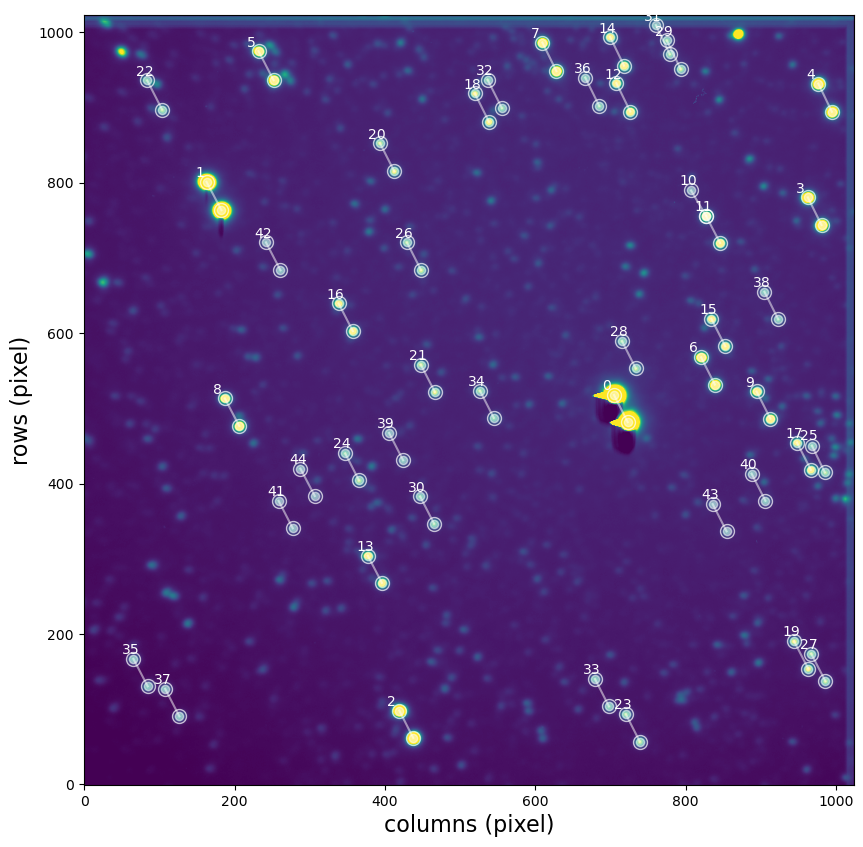

In [12]:
s4plt.plot_sci_polar_frame(polar_stack_example)

Now print one of the catalogs to see its contents

In [14]:
catalog = 'CATALOG_POL_N_AP010'
pd.DataFrame(hdul[catalog].data)

,SRCINDEX,RA,DEC,X,Y,FWHMX,FWHMY,MAG,EMAG,SKYMAG,ESKYMAG,APER,FLAG
0,0,258.125026,-24.248643,722.832369,481.727293,10.983096,10.983096,-12.015870,0.000372,-9.167396,0.001096,10,0
1,1,258.182265,-24.223897,182.576870,763.564149,9.638374,9.638374,-11.387577,0.000521,-9.089148,0.001345,10,0
2,2,258.152929,-24.289115,437.601074,61.768041,8.887891,8.887891,-10.216968,0.001023,-9.047437,0.001253,10,0
3,3,258.099395,-24.223022,980.618044,743.786753,8.226145,8.226145,-10.102703,0.001064,-9.126036,0.000867,10,0
4,4,258.098562,-24.208735,994.387714,894.458534,8.163924,8.163924,-10.056877,0.001108,-9.113859,0.000969,10,0
5,5,258.175793,-24.207300,251.879877,936.443865,8.772211,8.772211,-9.516896,0.001749,-9.102026,0.001455,10,0
6,6,258.113241,-24.243524,838.768151,531.641748,8.481659,8.481659,-9.570048,0.001502,-9.147283,0.000793,10,0
7,7,258.136762,-24.204905,628.048775,948.499110,8.425650,8.425650,-9.591494,0.001732,-9.158646,0.001547,10,0
8,8,258.178607,-24.250898,206.247294,476.571207,8.912382,8.912382,-9.190881,0.002131,-9.083556,0.001291,10,0
9,9,258.105416,-24.247533,912.607396,486.236107,8.310863,8.310863,-9.104135,0.002155,-9.128611,0.000976,10,0


Below we select the source with its index number assigned as the main target to be analyzed. Then we select other stars as comparisons for differential photometry. All indices are displayed in the image above.  

After selecting the stars we use the function `s4plt.plot_light_curve` to produce plots of the lightcurve data.

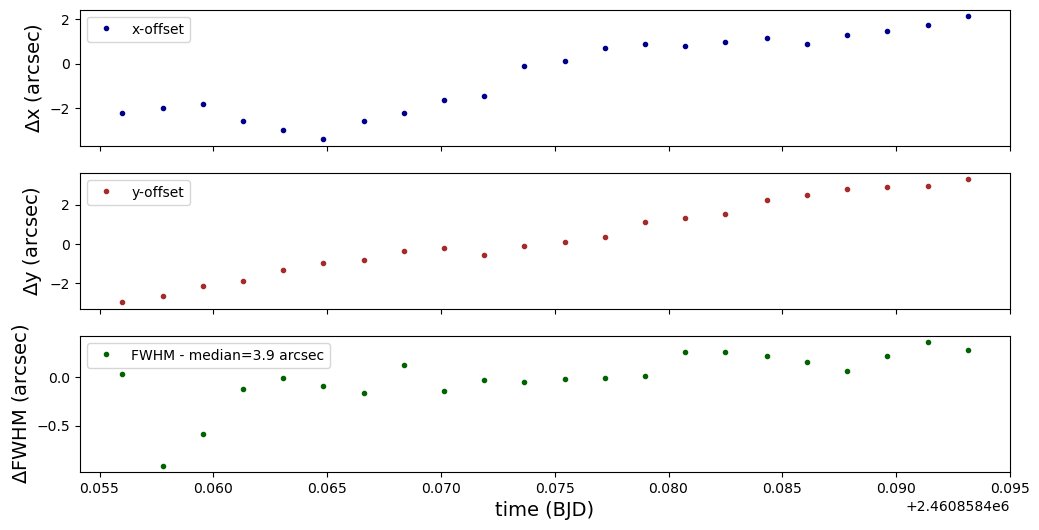

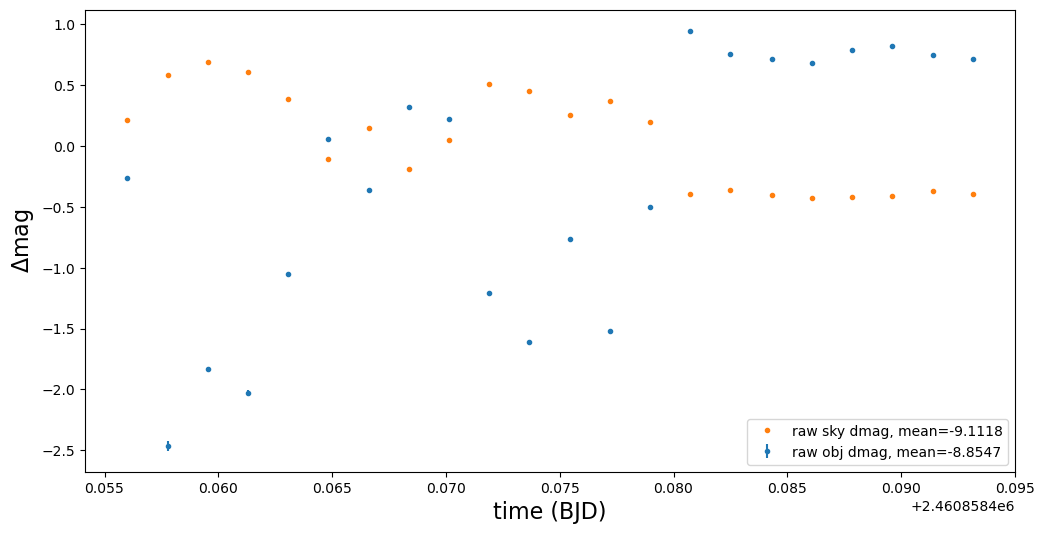

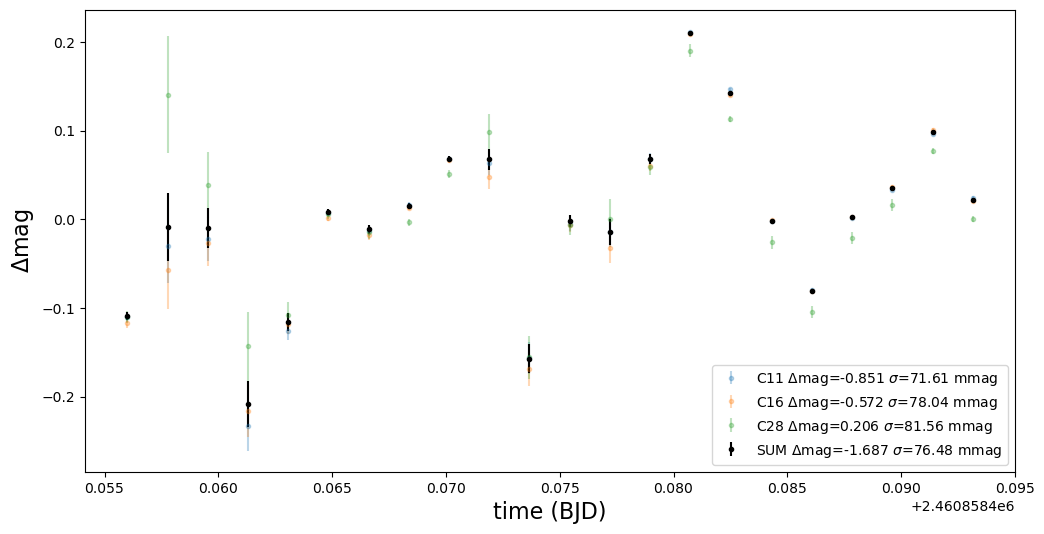

       TIME                x         ...       diffmagsum      
------------------ ----------------- ... ----------------------
2460858.4560017064 456.9853242439743 ...   -0.10905066681476239
 2460858.457772515 457.7353242439743 ...  -0.008547892804986468
 2460858.459537559 458.2353242439743 ...    -0.0096108264591388
2460858.4613027195 455.9853242439743 ...   -0.20789085315371736
2460858.4630693034 454.7353242439743 ...   -0.11596858863899318
2460858.4648340237 453.4853242439743 ...   0.008739994295473785
 2460858.466599439 455.9853242439743 ...  -0.011273021310503673
               ...               ... ...                    ...
2460858.4824950458 466.4853242439743 ...    0.14205924218517918
 2460858.484309753 466.9853242439743 ... -0.0020276911573562373
2460858.4860786395 466.2353242439743 ...   -0.08069519099599365
2460858.4878445864 467.4853242439743 ...  0.0020276911573562373
2460858.4896117137 467.9853242439743 ...    0.03541829442515532
2460858.4913802072 468.7353242439743 ...

In [16]:
catalog = 'CATALOG_PHOT_AP010'
target=21
comps=[11,16,28]

lc = s4plt.plot_light_curve(phot_lightcurve_example, target=target, comps=comps, nsig=10,
                            plot_coords=True, plot_rawmags=True, plot_sum=True,
                            plot_comps=True, catalog_name=catalog)

print(lc)

Now we open a polarimetry FITS product and print its basic information

In [18]:
polar = fits.open(polar_example)
polar.info()

Filename: /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs3/20250701_s4c3_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     159   ()      
  1  POLARIMETRY_AP005    1 BinTableHDU    258   45R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  POLARIMETRY_AP008    1 BinTableHDU    258   45R x 123C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D,

Below we print one of the catalog extensions

In [20]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data)

,APERINDEX,APER,SRCINDEX,RA,DEC,X1,Y1,X2,Y2,FWHM,...,FE0019,EFE0019,FO0020,EFO0020,FE0020,EFE0020,FO0021,EFO0021,FE0021,EFE0021
0,2.0,10.0,0.0,258.125026,-24.248643,704.690541,517.831111,722.832369,481.727293,12.744674,...,94045.897857,26.942889,94134.201872,27.087135,94613.867813,26.718692,92124.662288,49.518999,92936.256523,26.628520
1,2.0,10.0,1.0,258.182265,-24.223897,162.720766,801.284691,182.576870,763.564149,9.556787,...,67138.506823,23.095999,61445.271611,22.319301,67933.246338,23.361194,61288.698844,22.295014,66013.607901,23.035343
2,2.0,10.0,2.0,258.152929,-24.289115,419.110294,98.167919,437.601074,61.768041,8.829263,...,24586.675551,15.727356,20757.579199,14.690639,21791.563677,15.271147,21637.020027,14.852159,22961.308623,15.296844
3,2.0,10.0,3.0,258.099395,-24.223022,962.410482,780.574924,980.618044,743.786753,8.046729,...,20211.093552,13.942108,18687.703609,13.985913,18019.880991,13.234434,19552.285776,14.172007,18815.329836,13.481184
4,2.0,10.0,4.0,258.098562,-24.208735,976.331906,931.980352,994.387714,894.458534,7.977711,...,19427.676465,13.605090,17922.144897,13.713770,17332.659429,13.097137,18717.642413,13.908307,17918.961956,13.269988
5,2.0,10.0,5.0,258.175793,-24.207300,231.882670,975.209082,251.879877,936.443865,8.568421,...,14005.443850,12.552383,10859.124400,13.026006,12538.283497,12.334304,11372.532352,13.204715,13049.238199,12.372731
6,2.0,10.0,6.0,258.113241,-24.243524,820.444689,567.904837,838.768151,531.641748,8.285334,...,13884.390144,13.183302,11429.024680,11.996844,12379.084904,12.617392,11909.155103,12.248283,12933.633031,12.897071
7,2.0,10.0,7.0,258.136762,-24.204905,609.394799,986.544178,628.048775,948.499110,8.198638,...,13722.035405,14.351722,11647.432728,15.581396,12233.659316,13.841231,12182.164803,15.565992,12753.951545,14.004534
8,2.0,10.0,8.0,258.178607,-24.250898,187.058472,513.243078,206.247294,476.571207,8.530455,...,10496.097562,11.146778,8032.950789,11.151466,9311.179178,10.899763,8433.904829,11.319851,9749.996403,10.918468
9,2.0,10.0,9.0,258.105416,-24.247533,894.258245,522.483257,912.607396,486.236107,8.108919,...,8876.941753,13.727733,7421.558241,11.329983,7915.189577,13.564069,7734.512945,11.411961,8285.492450,13.591289


Then we can print all column names to check the data available in each catalog

In [22]:
pd.DataFrame(polar["POLARIMETRY_AP010"].data).columns

Index(['APERINDEX', 'APER', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2',
       'FWHM',
       ...
       'FE0019', 'EFE0019', 'FO0020', 'EFO0020', 'FE0020', 'EFE0020', 'FO0021',
       'EFO0021', 'FE0021', 'EFE0021'],
      dtype='object', length=123)

Finally, we can select the source of interest and then we get the polarimetry results using the function `get_polarimetry_results` from `sparc4.pipeline_lib` library:

2025-11-22 01:05:00,430 astropop - INFO - Normalization disabled.  [__init__]


2025-11-22 01:05:00,430 | INFO | Normalization disabled.


/home/fernando/anaconda3/lib/python3.12/site-packages/astropop/math/_deriv.py:29: RuntimeWarning: invalid value encountered in log
  return np.log(x)*np.power(x, y)
2025-11-22 01:05:00,442 root - INFO - Source index: i=21   [pipeline_lib]


2025-11-22 01:05:00,442 | INFO | Source index: i=21 


2025-11-22 01:05:00,443 root - INFO - Source RA=258.1518026217638 Dec=-24.245748488809642 mag=-12.593+-0.001  [pipeline_lib]


...

2025-11-22 01:05:00,564 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:05:00,898 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:05:00,898 | INFO | Substituting symbol \perp from STIXGeneral


2025-11-22 01:05:00,905 matplotlib.mathtext - INFO - Substituting symbol \perp from STIXGeneral  [_mathtext]


2025-11-22 01:05:00,905 | INFO | Substituting symbol \perp from STIXGeneral


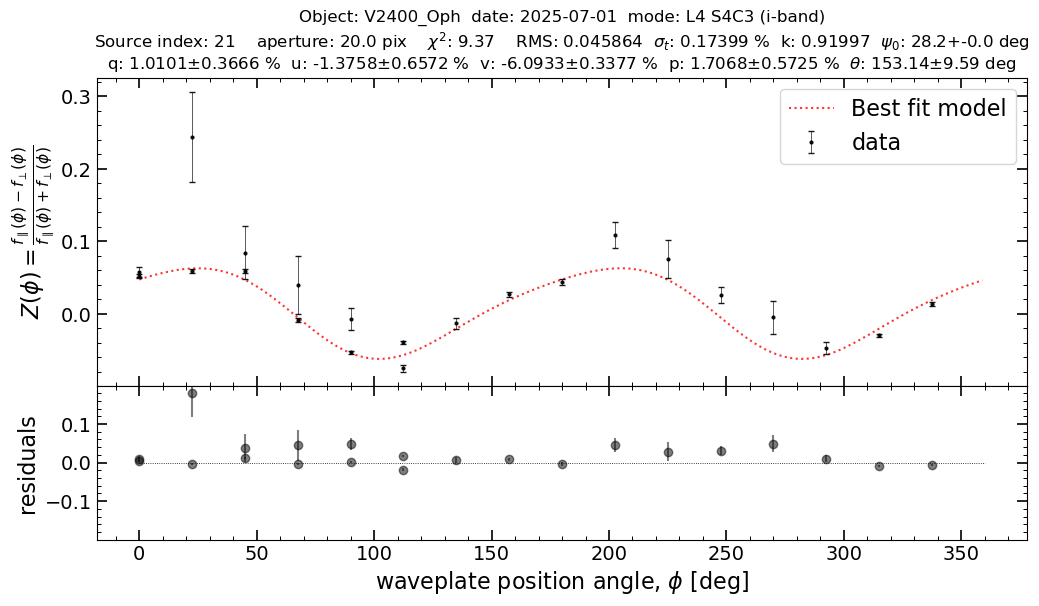

In [24]:
source_index = target

pol_results = s4pipelib.get_polarimetry_results(polar_example,
                                                source_index=source_index,
                                                min_aperture=5,
                                                max_aperture=21,
                                                plot=True,
                                                verbose=True)

Below we print all variables names for the measurements available in the polar product

In [26]:
for key in pol_results.keys():
    print(key, ":", pol_results[key])

POLAR_PRODUCT : /media/fernando/KINGSTON/Doutorado/2025/reduced/20250701/sparc4acs3/20250701_s4c3_Gain2_1.0_Conventional_2_V2400_Oph_POLAR_L4_polar.fits
SOURCE_INDEX : 21
POLARIMETRY_SUCCESS : True
APERTURE_INDEX : 6
APERTURE_RADIUS : 20.0
NEXPS : 22
MAG : -12.593+-0.001
RA : 258.1518026217638
DEC : -24.245748488809642
FWHM : 8.33426091916958
X1 : 447.6439937786901
Y1 : 558.2690204066421
X2 : 466.32665470925843
Y2 : 521.911566230509
WAVEPLATE_ANGLES : [  0.   22.5  45.   67.5  90.  112.5 135.  157.5 180.  202.5 225.  247.5
 270.  292.5 315.  337.5   0.   22.5  45.   67.5  90.  112.5]
ZI : [0.058+-0.007, 0.24+-0.06, 0.08+-0.04, 0.04+-0.04, -0.01+-0.02,
 -0.075+-0.005, -0.013+-0.008, 0.027+-0.003, 0.044+-0.004, 0.11+-0.02,
 0.08+-0.03, 0.03+-0.01, -0.00+-0.02, -0.047+-0.009, -0.029+-0.002,
 0.014+-0.002, 0.052+-0.002, 0.059+-0.003, 0.059+-0.002, -0.008+-0.002,
 -0.053+-0.002, -0.039+-0.002]
FO : [1770+-20, 270+-20, 420+-20, 350+-20, 770+-20, 2010+-10, 1450+-20,
 3040+-10, 2700+-20, 790+-

And below we show a simple example how to get one of these measurements out. For instance, we're getting the total polarization and the polarization angle. 

In [28]:
p = pol_results["P"]*100
pa = pol_results["THETA"]
print("Polarization: {} %  Angle of polarization: {} deg".format(p,pa) )

Polarization: 1.7+-0.6 %  Angle of polarization: 150+-10 deg deg


Finally, we show below an example of a polarimetric time series product. 

In [30]:
polar_ts = fits.open(polar_time_series_example)
pd.DataFrame(polar_ts[1].data)

ValueError: Big-endian buffer not supported on little-endian compiler

ValueError: Big-endian buffer not supported on little-endian compiler

In [31]:
pd.DataFrame(polar_ts[1].data).columns

Index(['TIME', 'SRCINDEX', 'RA', 'DEC', 'X1', 'Y1', 'X2', 'Y2', 'FWHM', 'MAG',
       'EMAG', 'Q', 'EQ', 'U', 'EU', 'V', 'EV', 'P', 'EP', 'THETA', 'ETHETA',
       'K', 'EK', 'ZERO', 'EZERO', 'NOBS', 'NPAR', 'CHI2', 'RMS', 'TSIGMA'],
      dtype='object')

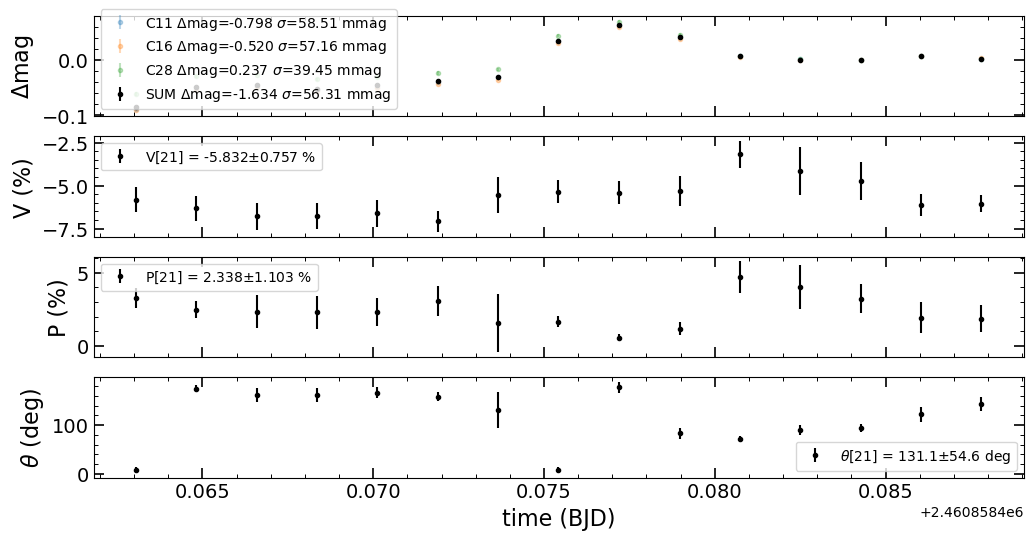

diffmag_C00000,diffmag_err_C00000,diffmag_C00001,diffmag_err_C00001,diffmag_C00002,diffmag_err_C00002,TIME,x1,y1,x2,y2,fwhm,mag,mag_err,magsum,magsum_err,diffmagsum,polarization_1,polarization_1_err,polarization_2,polarization_2_err
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-0.08837930794211957,0.0024477542013537253,-0.09045199646372737,0.00256793650257495,-0.06147078953461538,0.003531248972807803,2460858.463052296,447.6439937786901,558.2690204066421,466.32665470925843,521.911566230509,8.08515745045025,-10.639987198217934,0.0022162996964639,-12.35855490136366,0.003212407941999259,-0.08437302641913114,0.03302756199920325,0.006845252506479166,8.031702067957848,5.927601367912866
-0.05253867227937015,0.002252422286755926,-0.05364582129842255,0.0023680617217571548,-0.029806014167998995,0.003291611016349675,2460858.464820361,448.3939937786901,559.2690204066421,467.07665470925843,522.911566230509,8.027449865709109,-10.736091165464961,0.0020261447527300893,-12.4192012602919,0.003033156422249563,-0.04891541810034283,0.024853601034105652,0.005872443859411111,174.87947793463013,6.75764828399248
-0.04820738792608914,0.0021564175478614948,-0.04957828192562275,0.0022655605611494036,-0.02660539846849197,0.0031515190222104156,2460858.4665854,448.8939937786901,560.7690204066421,467.57665470925843,524.411566230509,8.113084000642903,-10.782391064854487,0.0019363128644970494,-12.461463147717007,0.002909819739548203,-0.0448774061359245,0.02337915168428877,0.0114114955150296,161.8765167801741,13.959820960876547
-0.05454532565903136,0.002103855194034065,-0.05632837749266173,0.0022077276265851605,-0.0349378772663691,0.0030602208770803925,2460858.4683510577,446.6439937786901,561.5190204066421,465.32665470925843,525.161566230509,8.12713549779377,-10.790996485298534,0.0018893298057446163,-12.476905100408892,0.0028207301222458654,-0.051713938383763036,0.02306476062557083,0.011226268540757162,161.70636265517058,13.920425426383918
-0.04794885717868702,0.0019486634261869156,-0.05024030162653048,0.002043662763009176,-0.03120960591581401,0.0028359990444989337,2460858.4701182726,445.3939937786901,563.2690204066421,464.07665470925843,526.911566230509,8.159359407757396,-10.857422536299403,0.0017453667144536637,-12.537422155622002,0.0026225602593838264,-0.04580494259600343,0.023403315117227434,0.009457875012120632,166.50383907305616,11.55798757533866
-0.03946331854870522,0.0019890341725179164,-0.04318514179668931,0.002086673079436356,-0.023558869885665246,0.002903662423617032,2460858.4718835945,444.1439937786901,564.2690204066421,462.82665470925843,527.911566230509,8.12713549779377,-10.832027784083573,0.0017796041980092823,-12.504203883054355,0.002690862992702748,-0.03798142224418655,0.03081569264379958,0.01006445206869107,157.9812694715766,9.340803482555552
-0.03166662965804257,0.0021652345671868325,-0.03555404201980039,0.00227372890829129,-0.01708239200875994,0.003158443789110758,2460858.4736490967,446.6439937786901,564.7690204066421,465.32665470925843,528.411566230509,8.21774413292989,-10.746899388066923,0.0019376137820982713,-12.411571021915462,0.002927594497634717,-0.03047695712194276,0.015562144264165956,0.0199792534809721,131.08595573968586,36.71773245744463
0.034350951730084844,0.0016736698387886937,0.031251287747465994,0.0017605837312799609,0.04418854462178601,0.003283081583088968,2460858.4754160736,447.6439937786901,566.0190204066421,466.32665470925843,529.661566230509,8.25827061543903,-11.04997786260345,0.001472700958294194,-12.649186616266867,0.003189499356898304,0.0349859230631786,0.016592828253175956,0.0037771190146390337,7.730732710951859,6.510379193372275
0.06305815887543709,0.0015441308988173536,0.059266115094022354,0.0016250166697796837,0.06888508265089577,0.0030660332307263145,2460858.4771816265,449.3939937786901,566.5190204066421,468.07665470925843,530.161566230509,8.25827061543903,-11.150420980437632,0.0013484778607521

In [32]:
s4plt.plot_polar_time_series(polar_time_series_example, 
                             target=target, 
                             comps=comps, 
                             plot_total_polarization=True, 
                             plot_polarization_angle=True)